In [12]:
import numpy as np
import matplotlib.pyplot as plt
import hashlib
from copy import deepcopy
from mpl_toolkits.mplot3d import Axes3D
#from qiskit.circuit.library import efficient_su2
from qiskit.circuit.library import EfficientSU2
from qiskit.quantum_info import Statevector
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform
import numpy as np

# ==========================================
# 1. UTILITY: TRACKING & LOGGING
# ==========================================
class LandscapeTracker:
    def __init__(self):
        self.history = []
        self.stage_markers = []
        self.current_iter = 0

    def log(self, energy):
        self.history.append(energy)
        self.current_iter += 1

    def mark_stage(self, name):
        self.stage_markers.append((self.current_iter, name))

# ==========================================
# 2. ANALYSIS: STABILITY & CONVERGENCE (KABSCH)
# ==========================================
class StabilityAnalyzer:
    """
    Tools to evaluate if the folding results are structurally consistent.
    Implements the Kabsch algorithm for optimal superposition.
    """
    
    @staticmethod
    def kabsch_rmsd(P, Q):
        """
        Calculates the RMSD between two sets of coordinates P and Q
        after optimally rotating P to align with Q.
        P and Q must be (N, 3) matrices.
        """
        # 1. Centering
        P_centered = P - np.mean(P, axis=0)
        Q_centered = Q - np.mean(Q, axis=0)
        
        # 2. Covariance Matrix
        H = np.dot(P_centered.T, Q_centered)
        
        # 3. SVD
        V, S, Wt = np.linalg.svd(H)
        
        # 4. Rotation Matrix
        d = (np.linalg.det(V) * np.linalg.det(Wt)) < 0.0
        if d: 
            S[-1] = -S[-1]
            V[:, -1] = -V[:, -1]
        
        R = np.dot(V, Wt)
        
        # 5. Rotate and Diff
        P_rotated = np.dot(P_centered, R)
        diff = P_rotated - Q_centered
        rms = np.sqrt(np.mean(np.sum(diff**2, axis=1)))
        
        return rms, P_rotated + np.mean(Q, axis=0) # Return RMSD and Aligned Coords

    @staticmethod
    def analyze_convergence(results, top_k=5):
        """
        Calculates pairwise RMSD between the top K lowest energy structures.
        """
        # Sort by Energy (lowest first)
        sorted_results = sorted(results, key=lambda x: x['energy'])
        best_k = sorted_results[:top_k]
        n = len(best_k)
        
        if n < 2: return
        
        print(f"\n--- CONVERGENCE ANALYSIS (Top {n} Structures) ---")
        
        rmsd_matrix = np.zeros((n, n))
        
        # Print Header
        print("      ", end="")
        for i in range(n): print(f" #{i:<4}", end="")
        print("\n" + "-"*60)
        
        for i in range(n):
            print(f"Ref #{i} |", end="")
            for j in range(n):
                if i == j:
                    rmsd_matrix[i, j] = 0.0
                else:
                    # Note: Using all atoms for RMSD. Ideally filter for 'CA' only.
                    rmsd, _ = StabilityAnalyzer.kabsch_rmsd(best_k[i]['coords'], best_k[j]['coords'])
                    rmsd_matrix[i, j] = rmsd
                
                print(f" {rmsd_matrix[i, j]:.2f} ", end="")
            print(f"  (E={best_k[i]['energy']:.1f})")
            
        avg_rmsd = np.sum(rmsd_matrix) / (n*(n-1))
        print(f"\nAverage Pairwise RMSD: {avg_rmsd:.2f} Angstroms")
        
        if avg_rmsd < 2.0:
            print(">>> VERDICT: STABLE. High confidence in prediction.")
        elif avg_rmsd < 4.5:
            print(">>> VERDICT: FLEXIBLE. Core is stable, loops vary.")
        else:
            print(">>> VERDICT: UNSTABLE. No dominant basin found.")

# ==========================================
# 3. CORE: QUANTUM FOLDER
# ==========================================
class QuantumBiophysicsFolder:
    """
    A Hybrid Quantum-Classical Protein Folder.
    
    ARCHITECTURE:
    1. Quantum Actor (The Generator): 
       Uses a parameterized quantum circuit (VQE ansatz) to generate a probability distribution.
       These probabilities are mapped to physical torsion angles (phi, psi, chi).
       
    2. Classical Critic (The Energy Function):
       Constructs the 3D geometry from those angles and evaluates its physical stability
       using a custom force field (hydrophobicity, electrostatics, H-bonds, etc.).
       
    3. Optimization Loop:
       Classical optimizers (COBYLA/SLSQP) tune the quantum circuit parameters to minimize the energy.

    REFERENCES:
    1. Hydrophobicity: Kyte, J., & Doolittle, R. F. (1982). A simple method for displaying the hydropathic character of a protein.
    2. Electrostatics: CHARMM22 / OPLS-AA Force Fields (Approximated partial charges).
    3. VdW Radii: Bondi, A. (1964). Van der Waals volumes and radii.
    4. Topology: Engh, R. A., & Huber, R. (1991). Accurate bond and angle parameters for X-ray protein structure refinement.
    5. Heuristics: Manual tuning ("Quantum Velcro") for folding convergence.
    """

    def __init__(self, sequence, force_field='charmm'):
        """
        Initialize the folder.
        
        Args:
            sequence (str): Amino acid sequence (e.g., 'MAG').
            force_field (str): 'charmm', 'amber', or 'opls'. Determines partial charges.
        """
        self.sequence = sequence.upper()
        self.n_residues = len(sequence)
        self.force_field = force_field.lower()
        
        print(f"--- INITIALIZING QUANTUM BIOPHYSICS FOLDER ---")
        print(f"--- FORCE FIELD: {self.force_field.upper()} ---")
        
        # --- PARAMETERS (Force Field Constants) ---

        # 1. HYDROPHOBICITY SCALE
        # Ref: Kyte, J., & Doolittle, R. F. (1982). J. Mol. Biol. 157, 105-132.
        self.HYDROPHOBICITY = {
            'I': 4.5, 'V': 4.2, 'L': 3.8, 'F': 2.8, 'C': 2.5,
            'M': 1.9, 'A': 1.8, 'G': -0.4, 'T': -0.7, 'S': -0.8,
            'W': -0.9, 'Y': -1.3, 'P': -1.6, 'H': -3.2, 'E': -3.5,
            'Q': -3.5, 'D': -3.5, 'N': -3.5, 'K': -3.9, 'R': -4.5
        }
        
        # 2. PARTIAL CHARGES (Coulomb's Law)
        # We now support switching between major force field approximations.
        # While coarse-grained, these capture the distinct dipole strengths of each FF.
        
        # BASE (Shared Ions)
        common_charges = {
            'OXT': -1.0, 
            'NZ': 1.0, 'NH1': 0.5, 'NH2': 0.5, 
            'OD1': -0.5, 'OD2': -0.5, 'OE1': -0.5, 'OE2': -0.5,
            'ND2': 0.5, 'NE2': 0.5, 
            'SG': -0.1, 'SD': -0.1,
            'HE2': 0.4, 'ND1': -0.4, # His
        }

        # CHARMM22 (The original default)
        # Strong dipoles, balanced C-alpha.
        charmm_charges = {
            'N': -0.47, 'H': 0.31, 'CA': 0.07, 'C': 0.51, 'O': -0.51,
            'OG': -0.4, 'HG': 0.4, 'OG1': -0.4, 'HG1': 0.4, 'OH': -0.4, 'HH': 0.4,
            'NE1': -0.3, 'HE1': 0.3
        }
        
        # AMBER (ff94/99/14SB approx)
        # N is slightly less negative, C=O is very polar. C-alpha is often neutral.
        amber_charges = {
            'N': -0.42, 'H': 0.27, 'CA': 0.00, 'C': 0.60, 'O': -0.57,
            'OG': -0.6, 'HG': 0.4, 'OG1': -0.6, 'HG1': 0.4, 'OH': -0.5, 'HH': 0.4, # Ambient hydroxyls often stronger
            'NE1': -0.4, 'HE1': 0.3
        }

        # OPLS-AA
        # Very standardized backbone dipoles (+0.5/-0.5).
        opls_charges = {
            'N': -0.50, 'H': 0.30, 'CA': 0.14, 'C': 0.50, 'O': -0.50,
            'OG': -0.7, 'HG': 0.4, 'OG1': -0.7, 'HG1': 0.4, 'OH': -0.7, 'HH': 0.4,
            'NE1': -0.4, 'HE1': 0.35
        }

        # Select Strategy
        self.CHARGES = common_charges.copy()
        if self.force_field == 'amber':
            self.CHARGES.update(amber_charges)
        elif self.force_field == 'opls':
            self.CHARGES.update(opls_charges)
        else: # Default to CHARMM
            if self.force_field != 'charmm':
                print(f" > Warning: Unknown force field '{self.force_field}'. Defaulting to CHARMM.")
            self.CHARGES.update(charmm_charges)
        
        # 3. VAN DER WAALS RADII (Angstroms)
        # Ref: Bondi, A. (1964). J. Phys. Chem. 68, 441-451.
        self.VDW_RADII = {'H': 0.6, 'C': 1.7, 'N': 1.55, 'O': 1.52, 'S': 1.8}
        
        # 4. SIDE CHAIN TOPOLOGY
        # Ref: Engh, R. A., & Huber, R. (1991). Acta Cryst. A47, 392-400.
        self.SIDE_CHAIN_TOPO = {
            'G': [],
            'A': [('CB', 'CA', 1.53, 1.91, 2.1)],
            
            # Hydrophobic
            'V': [('CB', 'CA', 1.53, 1.91, 'chi1'), 
                  ('CG1', 'CB', 1.52, 1.91, 'chi2'), ('CG2', 'CB', 1.52, 1.91, 'chi2_branch')],
            'L': [('CB', 'CA', 1.53, 1.91, 'chi1'), 
                  ('CG', 'CB', 1.52, 1.91, 'chi2'), 
                  ('CD1', 'CG', 1.52, 1.91, 'chi3'), ('CD2', 'CG', 1.52, 1.91, 'chi3_branch')],
            'I': [('CB', 'CA', 1.53, 1.91, 'chi1'), 
                  ('CG1', 'CB', 1.54, 1.91, 'chi2'), ('CD1', 'CG1', 1.52, 1.91, 'chi3'),
                  ('CG2', 'CB', 1.54, 1.91, 'chi2_branch')],
            'M': [('CB', 'CA', 1.53, 1.91, 'chi1'), ('CG', 'CB', 1.52, 1.91, 'chi2'),
                  ('SD', 'CG', 1.81, 1.91, 'chi3'), ('CE', 'SD', 1.79, 1.76, 'chi4')],
            'P': [('CB', 'CA', 1.53, 1.80, 'chi1'), ('CG', 'CB', 1.50, 1.82, 'chi2'),
                  ('CD', 'CG', 1.52, 1.83, 'chi3')], 

            # Aromatic
            'F': [('CB', 'CA', 1.53, 1.91, 'chi1'), ('CG', 'CB', 1.50, 1.91, 'chi2'),
                  ('CD1', 'CG', 1.39, 2.09, 1.57), ('CD2', 'CG', 1.39, 2.09, -1.57),
                  ('CE1', 'CD1', 1.39, 2.09, 3.14), ('CE2', 'CD2', 1.39, 2.09, 3.14),
                  ('CZ', 'CE1', 1.39, 2.09, 0.0)],
            'Y': [('CB', 'CA', 1.53, 1.91, 'chi1'), ('CG', 'CB', 1.50, 1.91, 'chi2'),
                  ('CD1', 'CG', 1.39, 2.09, 1.57), ('CD2', 'CG', 1.39, 2.09, -1.57),
                  ('CE1', 'CD1', 1.39, 2.09, 3.14), ('CE2', 'CD2', 1.39, 2.09, 3.14),
                  ('CZ', 'CE1', 1.39, 2.09, 0.0), 
                  ('OH', 'CZ', 1.37, 2.09, 3.14), ('HH', 'OH', 0.96, 1.83, 'chi3')], 
            'W': [('CB', 'CA', 1.53, 1.91, 'chi1'), ('CG', 'CB', 1.50, 1.91, 'chi2'),
                  ('CD1', 'CG', 1.37, 2.15, 1.0), ('CD2', 'CG', 1.43, 2.15, -1.0),
                  ('NE1', 'CD1', 1.38, 1.90, 3.14), ('HE1', 'NE1', 1.01, 2.09, 0.0), 
                  ('CE2', 'CD2', 1.40, 1.90, 0.0), ('CE3', 'CD2', 1.40, 2.30, 3.14), 
                  ('CZ2', 'CE2', 1.40, 2.10, 0.0), ('CZ3', 'CE3', 1.40, 2.10, 0.0), 
                  ('CH2', 'CZ2', 1.40, 2.10, 0.0)], 

            # Polar / Charged
            'S': [('CB', 'CA', 1.53, 1.91, 'chi1'), ('OG', 'CB', 1.42, 1.91, 'chi2'),
                  ('HG', 'OG', 0.96, 1.83, 'chi3')], 
            'T': [('CB', 'CA', 1.53, 1.91, 'chi1'), 
                  ('OG1', 'CB', 1.43, 1.91, 'chi2'), ('HG1', 'OG1', 0.96, 1.83, 'chi3'), 
                  ('CG2', 'CB', 1.53, 1.91, 'chi2_branch')],
            'C': [('CB', 'CA', 1.53, 1.91, 'chi1'), ('SG', 'CB', 1.81, 1.91, 'chi2')],
            'D': [('CB', 'CA', 1.53, 1.91, 'chi1'), ('CG', 'CB', 1.52, 1.91, 'chi2'),
                  ('OD1', 'CG', 1.25, 2.0, 1.0), ('OD2', 'CG', 1.25, 2.0, -1.0)],
            'N': [('CB', 'CA', 1.53, 1.91, 'chi1'), ('CG', 'CB', 1.52, 1.91, 'chi2'),
                  ('OD1', 'CG', 1.23, 2.09, 0.0), ('ND2', 'CG', 1.32, 2.09, 3.14)],
            'E': [('CB', 'CA', 1.53, 1.91, 'chi1'), ('CG', 'CB', 1.52, 1.91, 'chi2'),
                  ('CD', 'CG', 1.52, 1.91, 'chi3'), ('OE1', 'CD', 1.25, 2.0, 1.0), ('OE2', 'CD', 1.25, 2.0, -1.0)],
            'Q': [('CB', 'CA', 1.53, 1.91, 'chi1'), ('CG', 'CB', 1.52, 1.91, 'chi2'),
                  ('CD', 'CG', 1.52, 1.91, 'chi3'), ('OE1', 'CD', 1.23, 2.09, 0.0), ('NE2', 'CD', 1.32, 2.09, 3.14)],
            'K': [('CB', 'CA', 1.53, 1.91, 'chi1'), ('CG', 'CB', 1.52, 1.91, 'chi2'),
                  ('CD', 'CG', 1.52, 1.91, 'chi3'), ('CE', 'CD', 1.52, 1.91, 'chi4'),
                  ('NZ', 'CE', 1.49, 1.91, 'chi5')],
            'R': [('CB', 'CA', 1.53, 1.91, 'chi1'), ('CG', 'CB', 1.52, 1.91, 'chi2'),
                  ('CD', 'CG', 1.52, 1.91, 'chi3'), ('NE', 'CD', 1.46, 1.91, 'chi4'),
                  ('CZ', 'NE', 1.33, 2.15, 'chi5'), ('NH1', 'CZ', 1.33, 2.10, 0.0), ('NH2', 'CZ', 1.33, 2.10, 3.14)],
            'H': [('CB', 'CA', 1.53, 1.91, 'chi1'), ('CG', 'CB', 1.50, 1.91, 'chi2'),
                  ('ND1', 'CG', 1.38, 2.15, 1.0), ('CD2', 'CG', 1.36, 2.15, -1.0),
                  ('CE1', 'ND1', 1.32, 1.90, 0.0), 
                  ('NE2', 'CD2', 1.32, 1.90, 0.0), ('HE2', 'NE2', 1.01, 2.09, 0.0)], 
            
            'DEFAULT': [('CB', 'CA', 1.53, 1.91, 'chi1')]
        }

        # --- QUANTUM SETUP ---
        # 1. Map sequence to Degrees of Freedom (DoF)
        self.dof_map = []
        for i, aa in enumerate(self.sequence):
            self.dof_map.append({'res': i, 'type': 'phi'}) # Backbone torsion
            self.dof_map.append({'res': i, 'type': 'psi'}) # Backbone torsion
            
            # Add Sidechain torsions (chi)
            topo = self.SIDE_CHAIN_TOPO.get(aa, self.SIDE_CHAIN_TOPO['DEFAULT'])
            chis = set()
            for atom in topo:
                tor = atom[4]
                if isinstance(tor, str) and 'chi' in tor: chis.add(tor)
            for k in sorted(chis): self.dof_map.append({'res': i, 'type': k})
        
        self.total_angles = len(self.dof_map)
        
        # 2. Holographic Encoding
        # We only need log2(N) qubits to represent N angles in terms of statevector capacity.
        # This makes the algorithm scalable.
        self.n_qubits = max(2, int(np.ceil(np.log2(self.total_angles))))
        
        # 3. The Ansatz (The "Actor")
        # 'efficient_su2' is a heuristic circuit often used in VQE.
        # 'reps' controls depth. More reps = more expressive = harder to train.
        self.reps = int(np.ceil(self.total_angles / self.n_qubits)) + 2
        #self.ansatz = efficient_su2(self.n_qubits, reps=self.reps, entanglement='circular')
        self.ansatz = EfficientSU2(self.n_qubits, reps=self.reps, entanglement='circular')
        self.n_params = self.ansatz.num_parameters
        
        self.current_stage = 1
        
        # --- PRE-COMPUTE CACHE (Optimization) ---
        # We run the structure builder once with dummy data to figure out which atom is which.
        # This lets us optimize the energy function using Vectorization (NumPy) instead of slow loops.
        self._cache_initialized = False
        self._initialize_topology_cache()
        self.tracker = None  # TRACKER REFERENCE

    def _get_angles(self, params):
        """
        THE HOLOGRAPHIC MAPPING
        Maps Circuit Parameters (Theta) -> Torsion Angles (Phi/Psi/Chi).
        
        Logic:
        1. Assign parameters to the quantum circuit.
        2. Calculate the Statevector (Full wavefunction).
        3. Extract the 'Angle' (phase) of the complex amplitudes.
        4. Use the first N phases as our N torsion angles.
        """
        param_dict = dict(zip(self.ansatz.parameters, params))
        bound_circuit = self.ansatz.assign_parameters(param_dict)
        psi = Statevector(bound_circuit).data # Get complex amplitudes
        return np.angle(psi)[:self.total_angles] # Extract phases

    def _nerf_step(self, a, b, c, bond_len, bond_angle, torsion):
        """
        Natural Extension Reference Frame (NERF)
        This is the standard math for placing atom D given atoms A, B, C.
        
        Inputs:
        - a, b, c: Coordinates of previous 3 atoms.
        - bond_len: Distance c -> d
        - bond_angle: Angle b-c-d
        - torsion: Dihedral angle a-b-c-d
        """
        bc = c - b; bc_u = bc / (np.linalg.norm(bc) + 1e-9)
        ab = b - a; n = np.cross(ab, bc_u); n_u = n / (np.linalg.norm(n) + 1e-9)
        bx_n = np.cross(n_u, bc_u)
        
        # Construct rotation matrix column-wise
        M = np.column_stack((bc_u, bx_n, n_u))
        
        theta_supp = np.pi - bond_angle
        d = np.array([bond_len * np.cos(theta_supp), bond_len * np.cos(torsion) * np.sin(theta_supp), bond_len * np.sin(torsion) * np.sin(theta_supp)])
        
        return c + (M @ d)

    def build_full_structure(self, angle_vector):
        """
        Constructs the full 3D Cartesian coordinates of the protein 
        based on the input torsion angles.
        """
        coords = []; labels = []; bonds = [] 
        
        # Map flat angle vector back to semantic names (e.g., '0_phi', '0_psi')
        angle_dict = {f"{x['res']}_{x['type']}": val for x, val in zip(self.dof_map, angle_vector)}
        
        # --- 1. INITIALIZE BACKBONE START ---
        # First 3 atoms (N, CA, C) are placed statically to establish a frame of reference.
        coords.extend([np.array([0,0,0]), np.array([1.46,0,0]), np.array([1.46 + 1.51*np.cos(1.9), 1.51*np.sin(1.9), 0])])
        labels.extend([(0, 'N', 'N'), (0, 'CA', 'C'), (0, 'C', 'C')])
        bonds.extend([(0,1), (1,2)]) 
        
        # --- 2. MAIN RESIDUE LOOP ---
        for i in range(self.n_residues):
            
            # Helper to find index of atoms in the 'coords' list
            def get_idx(r, n):
                for k in range(len(labels)-1, -1, -1): 
                    if labels[k][0] == r and labels[k][1] == n: return k
                return -1

            idx_N = get_idx(i, 'N'); idx_CA = get_idx(i, 'CA'); idx_C = get_idx(i, 'C')
            
            # --- BUILD SIDE CHAIN ---
            topo = self.SIDE_CHAIN_TOPO.get(self.sequence[i], self.SIDE_CHAIN_TOPO['DEFAULT'])
            sc_map = {} 
            for atom_def in topo:
                name, elem, b_len, b_ang, tor_def = atom_def
                
                # Determine Torsion Value
                t_val = 0.0
                if isinstance(tor_def, str) and 'chi' in tor_def:
                    t_val = angle_dict.get(f"{i}_{tor_def.replace('_branch','')}", 0.0)
                    if 'branch' in tor_def: t_val += 2.09 # Offset for branched chains (Val/Leu)
                else: t_val = tor_def # Fixed angle

                # Special Case: First Sidechain Atom (CB) connects to CA
                # Requires calculating the bisector of N-CA-C to place it correctly.
                if name == 'CB': 
                    u_nc = coords[idx_N] - coords[idx_CA]; u_cc = coords[idx_C] - coords[idx_CA]
                    n_plane = np.cross(u_nc, u_cc); n_plane /= (np.linalg.norm(n_plane)+1e-9)
                    u_mid = -(u_nc + u_cc); u_mid /= (np.linalg.norm(u_mid)+1e-9)
                    p_CB = coords[idx_CA] + (b_len * (np.cos(0.9)*u_mid + np.sin(0.9)*n_plane))
                    coords.append(p_CB); labels.append((i, name, elem)); bonds.append((idx_CA, len(coords)-1))
                    sc_map['CB'] = len(coords) - 1
                else:
                    # General NERF placement for rest of sidechain
                    p_name = 'CB'
                    # Determine Parent (Simple logic for standard topologies)
                    if name.startswith('CD'): p_name = 'CG'
                    if name.startswith('CE'): p_name = 'CD'
                    if name.startswith('CZ'): p_name = 'CE'
                    if name.startswith('NZ'): p_name = 'CE'
                    if name.startswith('OE') or name.startswith('OD'): p_name = 'CD' if name.startswith('OE') else 'CG'
                    if name.startswith('SG'): p_name = 'CB'
                    if name.startswith('CG'): p_name = 'CB'
                    if name.startswith('CD') and self.sequence[i] == 'L': p_name = 'CG'
                    
                    # New Parent Mappings for Explicit Hydrogens
                    if name.startswith('HG') and name != 'HG1': p_name = 'OG'
                    if name == 'HG1': p_name = 'OG1'
                    if name == 'HH': p_name = 'OH'
                    if name == 'HE1': p_name = 'NE1'
                    if name == 'HE2': p_name = 'NE2'

                    idx_c = sc_map.get(p_name, -1)
                    if idx_c == -1: idx_c = len(coords) - 1
                    c = coords[idx_c]
                    
                    grandp = 'CA' if p_name == 'CB' else 'CB'
                    # More specific Grandparent mapping for Hydrogens to ensure correct angle
                    if p_name == 'OG': grandp = 'CB'
                    if p_name == 'OG1': grandp = 'CB'
                    if p_name == 'OH': grandp = 'CZ'
                    if p_name == 'NE1': grandp = 'CD1'
                    if p_name == 'NE2': grandp = 'CD2' # For His

                    if grandp == 'CA': b = coords[idx_CA]; a = coords[idx_N]
                    else: b = coords[sc_map.get(grandp, idx_c-1)]; a = coords[idx_CA]
                    
                    new_pos = self._nerf_step(a, b, c, b_len, b_ang, t_val)
                    coords.append(new_pos); labels.append((i, name, elem)); bonds.append((idx_c, len(coords)-1))
                    sc_map[name] = len(coords) - 1

            # --- BUILD BACKBONE OXYGEN (Carbonyl) ---
            p_O = self._nerf_step(coords[idx_N], coords[idx_CA], coords[idx_C], 1.23, 2.1, np.pi) 
            coords.append(p_O); labels.append((i, 'O', 'O')); bonds.append((idx_C, len(coords)-1))
            
            # --- BUILD NEXT RESIDUE BACKBONE (N, CA, C) ---
            if i < self.n_residues - 1:
                psi = angle_dict.get(f"{i}_psi", -0.5)
                p_next_N = self._nerf_step(coords[idx_N], coords[idx_CA], coords[idx_C], 1.33, 2.0, psi)
                coords.append(p_next_N); labels.append((i+1, 'N', 'N')); bonds.append((idx_C, len(coords)-1))
                
                omega = np.pi # Peptide bond is planar (trans)
                p_next_CA = self._nerf_step(coords[idx_CA], coords[idx_C], p_next_N, 1.46, 2.1, omega)
                coords.append(p_next_CA); labels.append((i+1, 'CA', 'C')); bonds.append((len(coords)-2, len(coords)-1))
                
                phi = angle_dict.get(f"{i+1}_phi", -1.0)
                p_next_C = self._nerf_step(coords[idx_C], p_next_N, p_next_CA, 1.51, 1.9, phi)
                coords.append(p_next_C); labels.append((i+1, 'C', 'C')); bonds.append((len(coords)-2, len(coords)-1))

        return np.array(coords), labels, bonds

    def _initialize_topology_cache(self):
        """
        Runs structure builder once to determine static properties of atoms.
        Allows vectorization of Charges, Radii, and Types.
        """
        # Build with dummy zeros to get lists
        dummy_coords, self.static_labels, _ = self.build_full_structure(np.zeros(self.total_angles))
        n_atoms = len(dummy_coords)
        
        # 1. Map Atom Index -> Residue Index
        self.atom_to_res = np.array([x[0] for x in self.static_labels], dtype=int)
        self.atom_names = np.array([x[1] for x in self.static_labels])
        self.atom_elems = np.array([x[2] for x in self.static_labels])
        
        # 2. Pre-calculate Charges (Vectorized)
        self.q_vector = np.zeros(n_atoms)
        for k, (rid, name, elem) in enumerate(self.static_labels):
            q = self.CHARGES.get(name, 0.0)
            res_name = self.sequence[rid]
            
            # --- LOGIC PATCH: RESOLVE CHARGE NAME COLLISIONS ---
            # NE2 is ambiguous: It is an Amide (+0.5) in Gln, but an Amine (-0.4) in Neutral His.
            if res_name == 'H':
                if name == 'NE2': q = -0.4 
                if name == 'ND1': q = -0.4 
            
            # Apply Terminal Capping Logic (Neutralize ends usually)
            if rid == 0 or rid == self.n_residues - 1:
                if name in ['N', 'CA', 'C', 'O', 'OXT', 'H1', 'H2', 'H3', 'H']: q = 0.0
            self.q_vector[k] = q
        
        # 3. Pre-calculate VdW Radii (Vectorized)
        self.vdw_radii_vector = np.array([self.VDW_RADII.get(x[2], 1.7) for x in self.static_labels])
        
        # 4. Masks
        # Mask for heavy atoms (not H) - useful for Sterics
        self.mask_heavy = np.array([not x.startswith('H') for x in self.atom_names], dtype=bool)
        
        # Mask for Hydrophobic atoms (SASA)
        hydro_res_set = {'ALA','VAL','LEU','ILE','MET','PHE','TRP','PRO','CYS'}
        self.mask_hydrophobic = np.zeros(n_atoms, dtype=bool)
        for k, (rid, name, _) in enumerate(self.static_labels):
            if self.sequence[rid] in hydro_res_set and name.startswith('C'):
                self.mask_hydrophobic[k] = True
                
        # Mask for Bonded/Neighbor Exclusions (i, i+1 residues)
        # We generally don't calculate VdW/Electrostatics for atoms in the same or adjacent residues
        res_diff_matrix = np.abs(self.atom_to_res[:, None] - self.atom_to_res[None, :])
        self.mask_non_bonded = (res_diff_matrix >= 2) 
        
        # Identify indices for specific calculations to avoid string parsing in loop
        self.idx_N_atoms = np.where(self.atom_names == 'N')[0]
        self.idx_O_atoms = np.where(self.atom_names == 'O')[0]
        self.idx_SG_atoms = np.where(self.atom_names == 'SG')[0]
        
        self._cache_initialized = True

    def energy_function(self, params):
        """
        THE CRITIC (Objective Function)
        Evaluates how "physically good" the protein structure is.
        Lower Energy = Better Fold.
        """
        if not self._cache_initialized: self._initialize_topology_cache()
        
        # ==========================================
        # STAGE CONTROLLER (Guided Relaxation)
        # ==========================================
        # Ref: Heuristic Manual Tuning ("Quantum Velcro")
        # "Gamma" = Surface Tension. High Gamma forces the protein to squeeze into a ball (Hydrophobic collapse).
        # "Constraint" = End-to-end bias. Forces the ends together to form a hairpin.
        
        # Default: "Molding Mode" (Stages 1 & 2)
        gamma = 15.0              
        constraint_strength = 50.0 
        
        # Stage 3: RELAXATION
        if self.current_stage == 3:
            gamma = 5.0                # Relax surface tension
            constraint_strength = 5.0  # Relax end-to-end bias
            
        # 1. GENERATION: Get Geometry from Quantum Parameters
        angle_vec = self._get_angles(params)
        coords, _, _ = self.build_full_structure(angle_vec)
        
        total_energy = 0.0
        
        # --- VECTORIZED DISTANCE MATRIX (The heart of the physics engine) ---
        # Calculates distance between every pair of atoms in one massive matrix op.
        diffs = coords[:, None, :] - coords[None, :, :]
        D = np.sqrt(np.sum(diffs**2, axis=-1)) + 1e-9

        # ==========================================
        # 0. END-TO-END BIAS (The Variable Magnet)
        # ==========================================
        # Guarantees the U-shape topology, preventing "Elastic Recoil".
        ca_indices = [i for i, lbl in enumerate(self.static_labels) if lbl[1] == 'CA']
        if len(ca_indices) >= 2:
            start_ca = coords[ca_indices[0]]
            end_ca = coords[ca_indices[-1]]
            dist_ends = np.linalg.norm(start_ca - end_ca)
            
            # Target: 5.5 Angstroms (Ideal for Hairpin)
            e_constraint = constraint_strength * (dist_ends - 5.5)**2
            total_energy += e_constraint

        # ==========================================
        # 1. IMPLICIT SOLVENT (SASA - Hydrophobic Effect)
        # ==========================================
        # Approximates Solvent Accessible Surface Area.
        # Logic: Hydrophobic atoms want to be surrounded by other atoms (buried), not water.
        hydro_dists = D[self.mask_hydrophobic, :]
        weights = 1.0 / (1.0 + np.exp(1.0 * (hydro_dists - 6.0))) # Sigmoid count of neighbors < 6.0A
        neighbor_counts = np.sum(weights, axis=1) - 1.0 
        burial_fractions = neighbor_counts / 15.0 # Normalize: 15 neighbors = fully buried
        burial_fractions = np.clip(burial_fractions, 0.0, 1.0)
        exposed_area = 30.0 * (1.0 - burial_fractions)
        
        total_energy += np.sum(gamma * exposed_area)

        # ==========================================
        # 2. EXPLICIT H-BONDING (The Widened Zipper)
        # ==========================================
        # Checks for N-H ... O=C patterns.
        # This is critical for secondary structure (Alpha Helices / Beta Sheets).
        e_hbond = 0.0
        for i_n in self.idx_N_atoms:
            res_d = self.atom_to_res[i_n]
            idx_ca = i_n + 1
            idx_prev_c = i_n - 2 
            
            # Construct Hydrogen position (approximate)
            if idx_prev_c < 0 or self.atom_names[idx_prev_c] != 'C':
                pos_h = coords[i_n] + np.array([0,0,1.0]); pos_n = coords[i_n]
            else:
                p_c = coords[idx_prev_c]; p_n = coords[i_n]; p_ca = coords[idx_ca]
                v_nc = p_c - p_n; v_nc /= np.linalg.norm(v_nc)
                v_nca = p_ca - p_n; v_nca /= np.linalg.norm(v_nca)
                v_h = -(v_nc + v_nca); v_h /= np.linalg.norm(v_h)
                pos_h = p_n + v_h * 1.01; pos_n = p_n

            # Check all Oxygens
            o_coords = coords[self.idx_O_atoms]
            o_res = self.atom_to_res[self.idx_O_atoms]
            valid_mask = np.abs(o_res - res_d) >= 2 # Don't bond with immediate neighbors
            
            if not np.any(valid_mask): continue
            
            valid_o_coords = o_coords[valid_mask]
            d_ho = np.linalg.norm(valid_o_coords - pos_h, axis=1)
            close_mask = d_ho < 3.5
            if not np.any(close_mask): continue
            
            final_d_ho = d_ho[close_mask]
            final_o_coords = valid_o_coords[close_mask]
            
            # Angle check: H-bond must be roughly linear
            v_hn = pos_n - pos_h; v_hn /= np.linalg.norm(v_hn)
            v_ho = final_o_coords - pos_h
            norms = np.linalg.norm(v_ho, axis=1)[:, None]
            v_ho /= norms
            angle_cos = np.dot(v_ho, v_hn) 
            
            ang_mask = angle_cos < -0.4 
            
            # Energy calculation
            radial_term = np.exp(-(final_d_ho - 2.0)**2 / 0.5)
            angular_term = (np.abs(angle_cos) - 0.4) * 2.0 
            
            # Strength -25.0 is very strong ("Super Glue") to force folding
            term = -25.0 * radial_term * angular_term * ang_mask
            e_hbond += np.sum(term)

        total_energy += e_hbond

        # ==========================================
        # 3. ELECTROSTATICS (Coulomb)
        # ==========================================
        # q1*q2 / r^2
        Q_mat = np.outer(self.q_vector, self.q_vector)
        elec_mask = np.triu(self.mask_non_bonded, k=1) & (np.abs(Q_mat) > 0.0001)
        if np.any(elec_mask):
            r_elec = D[elec_mask]
            r_elec = np.maximum(r_elec, 1.0) # Cap distance to prevent infinity
            q_prod = Q_mat[elec_mask]
            total_energy += np.sum(83.0 * q_prod / (r_elec**2)) # 83.0 is approx Coulomb constant in these units

        # ==========================================
        # 3b. DISULFIDE BONDS (Cysteine Bridges)
        # ==========================================
        if len(self.idx_SG_atoms) > 1:
            sg_dists = D[np.ix_(self.idx_SG_atoms, self.idx_SG_atoms)]
            sg_mask = np.triu(np.ones_like(sg_dists, dtype=bool), k=1)
            valid_dists = sg_dists[sg_mask]
            
            # Attraction
            bond_strengths = np.exp(-(valid_dists - 2.05)**2 / 0.5)
            active_bonds = (valid_dists < 3.0)
            total_energy -= np.sum(25.0 * bond_strengths * active_bonds)
            
            # Valence Penalty (Don't form 3 bonds with one Sulfur)
            full_strengths = np.exp(-(sg_dists - 2.05)**2 / 0.5) * (sg_dists < 3.0)
            np.fill_diagonal(full_strengths, 0.0)
            saturation = np.sum(full_strengths, axis=1)
            overload = saturation - 1.0
            penalty_mask = overload > 0.1
            if np.any(penalty_mask):
                total_energy += np.sum(40.0 * (overload[penalty_mask])**2)

        # ==========================================
        # 4. STERICS (Softened Lennard-Jones)
        # ==========================================
        # Prevents atoms from being in the same place.
        Sigma_mat = self.vdw_radii_vector[:, None] + self.vdw_radii_vector[None, :]
        heavy_mat = self.mask_heavy[:, None] & self.mask_heavy[None, :]
        vdw_mask = np.triu(self.mask_non_bonded & heavy_mat, k=1)
        
        if np.any(vdw_mask):
            r_vdw = D[vdw_mask]
            s_vdw = Sigma_mat[vdw_mask]
            collision_mask = r_vdw < s_vdw # Only calculate if overlapping
            
            if np.any(collision_mask):
                r_col = r_vdw[collision_mask]
                s_col = s_vdw[collision_mask]
                
                # Standard Repulsion term
                term = (s_col / (r_col + 0.1)) ** 12
                
                # SOFTENING: Log-cap to prevent infinite energy (gradient explosion)
                high_e = term > 50.0
                if np.any(high_e): term[high_e] = 50.0 + np.log(term[high_e] - 49.0)
                
                total_energy += np.sum(0.1 * term)

        # ==========================================
        # LOCALS (Rotamer, Quadrupole, Rama, Geometry)
        # ==========================================
        angle_dict = {f"{x['res']}_{x['type']}": val for x, val in zip(self.dof_map, angle_vec)}
        
        # 5. Rotamers (Side chain preferences)
        total_energy += self._calculate_rotamer_energy(angle_dict)
        
        # 6. Aromatic Stacking (Pi-Pi interactions)
        total_energy += self._calculate_aromatic_quadrupole(coords, self.static_labels, self.atom_to_res)
        
        # 7. Ramachandran (Backbone torsion preferences)
        for i in range(self.n_residues):
             if f"{i}_phi" in angle_dict and f"{i}_psi" in angle_dict:
                phi = angle_dict[f"{i}_phi"]; psi = angle_dict[f"{i}_psi"]
                aa = self.sequence[i]
                
                # Ideal regions for Helix (-1, -0.8) and Sheet (-2.3, 2.4)
                d_helix = (phi - (-1.0))**2 + (psi - (-0.8))**2
                d_sheet = (phi - (-2.3))**2 + (psi - (2.4))**2
                
                if aa == 'G': # Glycine is flexible
                    d_helix_L = (phi - (1.0))**2 + (psi - (0.8))**2
                    d_sheet_L = (phi - (2.3))**2 + (psi - (-2.4))**2
                    dist_best = min(d_helix, d_sheet, d_helix_L, d_sheet_L)
                    total_energy += -3.0 * np.exp(-dist_best/0.6)
                else: # General case with forbidden regions
                    d_forbidden = (phi - (-2.0))**2 + (psi - (1.0))**2
                    term = -3.0 * np.exp(-d_helix/0.6) - 3.0 * np.exp(-d_sheet/0.6) + 5.0 * np.exp(-d_forbidden/1.0)
                    total_energy += term

        # 8. Geometry Integrity (Chirality, Planarity)
        total_energy += self._calculate_geometry_integrity(coords, self.static_labels, self.atom_to_res)

        if self.tracker:
            self.tracker.log(total_energy)
        
        return total_energy

    # --- KEEPING HELPERS (Standard implementations) ---
    def _calculate_rotamer_energy(self, angle_dict):
        """
        Ensures side chains adopt physically observed angles (gauche+, gauche-, trans).
        """
        energy = 0.0
        for i in range(self.n_residues):
            res_name = self.sequence[i]
            key = f"{i}_chi1"
            if key in angle_dict:
                chi = angle_dict[key]
                if res_name in ['VAL', 'ILE', 'THR']:
                    d_trans = (chi - 3.14159)**2; d_gplus = (chi - (-1.047))**2
                    energy += -3.0 * (np.exp(-d_trans/0.5) + np.exp(-d_gplus/0.5))
                elif res_name == 'PRO':
                    d_down = (chi - (-0.5))**2; d_up = (chi - (0.5))**2
                    energy += 10.0 * min(d_down, d_up)
                elif res_name in ['TRP', 'PHE', 'TYR', 'HIS']:
                    d_trans = (chi - 3.14159)**2; d_gplus = (chi - (-1.047))**2
                    energy += -2.0 * (np.exp(-d_trans/0.5) + np.exp(-d_gplus/0.5))
                else:
                    energy += 1.0 * (1.0 + np.cos(3.0 * chi))
        return energy

    def _calculate_aromatic_quadrupole(self, coords, labels, atom_to_res_idx):
        """
        Calculates stacking energy between aromatic rings (Phe, Tyr, Trp).
        Uses normal vectors to detect parallel stacking.
        """
        aromatics = []
        res_indices = np.unique(atom_to_res_idx)
        for r_idx in res_indices:
            if self.sequence[r_idx] in ['PHE', 'TYR', 'TRP']:
                mask = (atom_to_res_idx == r_idx)
                r_coords = coords[mask]
                r_names = self.atom_names[mask]
                
                ring_mask = np.isin(r_names, ['CG','CD1','CD2','CE1','CE2','CZ'])
                ring_atoms = r_coords[ring_mask]
                
                if len(ring_atoms) > 2:
                    centroid = np.mean(ring_atoms, axis=0)
                    v1 = ring_atoms[1] - ring_atoms[0]
                    v2 = ring_atoms[2] - ring_atoms[0]
                    normal = np.cross(v1, v2); normal /= (np.linalg.norm(normal)+1e-9)
                    aromatics.append((centroid, normal))
        
        energy_pi = 0.0
        n_aro = len(aromatics)
        if n_aro < 2: return 0.0
        
        for i in range(n_aro):
            for j in range(i+1, n_aro):
                c1, n1 = aromatics[i]; c2, n2 = aromatics[j]
                dist = np.linalg.norm(c1 - c2)
                if dist > 7.0: continue
                alignment = abs(np.dot(n1, n2))
                # T-stacking vs Parallel Stacking
                if alignment < 0.3 and 4.5 < dist < 6.0:
                     energy_pi -= 4.0 * np.exp(-(dist - 5.0)**2)
                elif alignment > 0.8 and 3.4 < dist < 4.5:
                     energy_pi -= 5.0 * np.exp(-(dist - 3.8)**2)
        return energy_pi

    def _calculate_geometry_integrity(self, coords, labels, atom_to_res_idx):
        """
        Penalizes physically impossible geometries (e.g. L-amino acids turning into D-amino acids).
        """
        energy = 0.0
        res_map = {}
        for k, lbl in enumerate(labels):
            r = lbl[0]; atom = lbl[1]
            if r not in res_map: res_map[r] = {}
            res_map[r][atom] = k
            
        for r in range(self.n_residues):
            atoms = res_map.get(r, {})
            res_name = self.sequence[r]
            
            # PRO Ring closure penalty
            if res_name == 'PRO' and 'CD' in atoms and 'N' in atoms:
                 d = np.linalg.norm(coords[atoms['CD']] - coords[atoms['N']])
                 if abs(d - 1.47) > 0.1: energy += 50.0 * (d - 1.47)**2
            
            # Chirality check (Ensure L-amino acids)
            if 'CA' in atoms and 'N' in atoms and 'C' in atoms and 'CB' in atoms:
                ca = coords[atoms['CA']]; n = coords[atoms['N']]
                c = coords[atoms['C']]; cb = coords[atoms['CB']]
                volume = np.dot(np.cross(n-ca, c-ca), cb-ca)
                if volume < 1.0: energy += 50.0 * (1.0 - volume)**2
            
            # Peptide Planarity (Omega angle should be 180 or 0)
            if r < self.n_residues - 1:
                next_atoms = res_map.get(r+1, {})
                if 'C' in atoms and 'CA' in atoms and 'N' in next_atoms and 'CA' in next_atoms:
                    idx1, idx2, idx3, idx4 = atoms['CA'], atoms['C'], next_atoms['N'], next_atoms['CA']
                    p1, p2, p3, p4 = coords[idx1], coords[idx2], coords[idx3], coords[idx4]
                    b1 = p2-p1; b2=p3-p2; b3=p4-p3
                    n1 = np.cross(b1, b2); n1/=np.linalg.norm(n1)
                    n2 = np.cross(b2, b3); n2/=np.linalg.norm(n2)
                    parallelism = np.dot(n1, n2)
                    
                    next_seq = self.sequence[r+1]
                    if next_seq == 'PRO': twist_penalty = min(1.0 - parallelism, 1.0 + parallelism)
                    else: twist_penalty = 1.0 - parallelism
                    
                    if twist_penalty > 0.05: energy += 20.0 * twist_penalty
        return energy

    def get_smart_initialization(self, n_attempts=20, seed=None):
        """
        Samples random parameters to find a good starting point (Basin Hopping).
        This avoids getting stuck in high-energy states immediately.
        
        REPRODUCIBILITY:
        Uses a hash of the sequence to seed the random number generator. 
        This ensures that every run with the same sequence starts from the same 
        initial geometry, allowing you to test energy function changes reliably.
        """
        if seed is not None:
            # Create a deterministic seed from the protein sequence
            seed = int(hashlib.sha256(self.sequence.encode('utf-8')).hexdigest(), 16) % (2**32)
        
        rng = np.random.default_rng(seed)
        
        print(f"--- SCOUTING: Checking {n_attempts} starting points ---")
        print(f" > Deterministic Seed: {seed} (Derived from Sequence)")
        
        best_params = None
        best_energy = float('inf')
        for i in range(n_attempts):
            trial_params = rng.uniform(-0.8, 0.8, self.n_params)
            e = self.energy_function(trial_params)
            if e < best_energy:
                best_energy = e
                best_params = trial_params
        print(f" > Best Start Found: Energy {best_energy:.2f}")
        return best_params

    def fold(self, max_iter=2000, initial_params=None):
        """
        MAIN EXECUTION LOOP
        Runs the 3-stage optimization curriculum.
        """
        print(f"--- STARTING QUANTUM FOLDING ---")
        self.tracker = LandscapeTracker() # Start Tracker

        # Initialization
        if initial_params is None:
            init_params = self.get_smart_initialization(n_attempts=max_iter)
        else:
            init_params = initial_params
        
        # STAGE 1: COLLAPSE
        # High Gamma (15.0) + Magnet Active
        # Purpose: Force the protein into a ball rapidly.
        print("Stage 1: Mechanical Collapse (High Force)...")
        self.tracker.mark_stage("Stage1")
        self.current_stage = 1
        res_1 = minimize(self.energy_function, init_params, method='COBYLA', options={'maxiter': max_iter, 'rhobeg': 1.0})
        print(f" > Collapse Energy: {res_1.fun:.2f}")

        # STAGE 2: REFINE
        # High Gamma (15.0) + Magnet Active + Precise Gradient Descent
        # Purpose: Fix local clashes while keeping the globular shape.
        print("Stage 2: Physics Refinement (High Force)...")
        self.tracker.mark_stage("Stage2")
        self.current_stage = 2
        res_2 = minimize(self.energy_function, res_1.x, method='SLSQP', tol=1e-6, options={'maxiter': max_iter, 'disp': True})
        print(f" > Refinement Energy: {res_2.fun:.2f}")
        
        # STAGE 3: RELAX
        # Low Gamma (2.0) + Magnet REMOVED
        # Purpose: Let the protein "breathe". H-bonds and Electrostatics take over
        # to find the native state.
        print("Stage 3: Natural Relaxation (Releasing Constraints)...")
        self.tracker.mark_stage("Stage3")
        self.current_stage = 3 
        res_3 = minimize(self.energy_function, res_2.x, method='SLSQP', tol=1e-6, options={'maxiter': max_iter, 'disp': True})
        print(f" > Relaxation Energy (Final Energy): {res_3.fun:.2f}")
        
        coords, labels, bonds = self.build_full_structure(self._get_angles(res_3.x))
        return coords, labels, bonds, self.tracker, res_3.x, res_3.fun

    def save_pdb(self, coords, labels, filename="structure.pdb", energy=0.0):
        """
        Saves the result to a PDB file viewable in PyMOL or Chimera.
        """
        with open(filename, 'w') as f:
            f.write(f"REMARK   1 ENERGY: {energy:.3f}\n")
            for k, (pos, (res_id, atom_name, elem)) in enumerate(zip(coords, labels)):
                res_name = self.sequence[res_id]
                f.write(f"ATOM  {k+1:>5}  {atom_name:<4} {res_name:>3} A{res_id+1:>4}    {pos[0]:8.3f}{pos[1]:8.3f}{pos[2]:8.3f}  1.00  0.00           {elem:>2}\n")

# ==========================================
# 4. ORCHESTRATOR: ENSEMBLE MANAGER
# ==========================================
class EnsembleFoldingManager:
    """
    Manages multiple independent folding runs (Monte Carlo / Multi-Start)
    """
    def __init__(self, folder_instance):
        self.folder = folder_instance
        self.results = [] 
    
    def prime_circuit(self, target_type='helix', seed=42):
        """
        Smart Initialization: Pre-optimizes circuit to output Secondary Structure angles.
        """
        print(f"--- PRIMING CIRCUIT FOR {target_type.upper()} ---")
        rng = np.random.default_rng(seed)

        if target_type == 'helix':
            t_phi, t_psi = np.deg2rad(-60.0), np.deg2rad(-45.0)
        elif target_type == 'sheet':
            t_phi, t_psi = np.deg2rad(-135.0), np.deg2rad(135.0)
        else:
            return rng.uniform(-0.8, 0.8, self.folder.n_params)

        targets = np.zeros(self.folder.total_angles)
        masks = np.zeros(self.folder.total_angles)
        
        for i, dof in enumerate(self.folder.dof_map):
            if dof['type'] == 'phi': targets[i] = t_phi; masks[i] = 1.0
            elif dof['type'] == 'psi': targets[i] = t_psi; masks[i] = 1.0
            
        def priming_cost(params):
            curr = self.folder._get_angles(params)
            diff = (curr - targets + np.pi) % (2 * np.pi) - np.pi
            return np.sum((diff * masks)**2)

        init_guess = rng.uniform(-0.1, 0.1, self.folder.n_params)
        res = minimize(priming_cost, init_guess, method='COBYLA', options={'maxiter': 200})
        print(f" > Priming Error: {res.fun:.4f}")
        return res.x

    def run_ensemble(self, n_runs=5, prime_strategy='mixed'):
        print(f"=== STARTING ENSEMBLE RUN ({n_runs} Trajectories) ===")
        self.results = []

        # Create a deterministic seed from the protein sequence
        # Retrieve the protein sequence from the folder object
        seed = int(hashlib.sha256(self.folder.sequence.encode('utf-8')).hexdigest(), 16) % (2**32)
        
        for i in range(n_runs):
            print(f"\n>> REPLICA {i+1}/{n_runs}")
            
            # Strategy Selection
            if prime_strategy == 'mixed':
                if i % 3 == 0: strat = 'helix'
                elif i % 3 == 1: strat = 'sheet'
                else: strat = 'random'
            else: strat = prime_strategy
                
            # Initialization
            if strat == 'random':
                start_params = self.folder.get_smart_initialization(n_attempts=50, seed=seed+i)
            else:
                start_params = self.prime_circuit(target_type=strat, seed=seed+i)
            
            # Execute Fold
            coords, _, _, tracker, final_params, final_energy = self.folder.fold(max_iter=20, initial_params=start_params)
            
            print(f" >> Replica {i+1} Final Energy: {final_energy:.2f}")
            self.results.append({
                'id': i, 'seed': seed+i, 'type': strat, 'energy': final_energy,
                'coords': coords, 'params': final_params, 'tracker': tracker
            })

    def evaluate_best(self):
        if not self.results: return None, None

        sorted_results = sorted(self.results, key=lambda x: x['energy'])
        best = sorted_results[0]
        
        print(f"\n=== ENSEMBLE EVALUATION ===")
        print(f"Best Candidate: ID {best['id']} (Init: {best['type']})")
        print(f"Lowest Energy:  {best['energy']:.4f}")
        
        if len(self.results) > 1:
            StabilityAnalyzer.analyze_convergence(self.results)

        return best

--- DIAGNOSING BACKBONE: YYDPETGTWY ---
--- INITIALIZING QUANTUM BIOPHYSICS FOLDER ---
--- FORCE FIELD: AMBER ---
=== STARTING ENSEMBLE RUN (3 Trajectories) ===

>> REPLICA 1/3
--- SCOUTING: Checking 50 starting points ---
 > Deterministic Seed: 313296767 (Derived from Sequence)
 > Best Start Found: Energy 524.90
--- STARTING QUANTUM FOLDING ---
Stage 1: Mechanical Collapse (High Force)...
 > Collapse Energy: 480.36
Stage 2: Physics Refinement (High Force)...
Iteration limit reached    (Exit mode 9)
            Current function value: 1062.7094881402325
            Iterations: 20
            Function evaluations: 2850
            Gradient evaluations: 20
 > Refinement Energy: 1062.71
Stage 3: Natural Relaxation (Releasing Constraints)...
Iteration limit reached    (Exit mode 9)
            Current function value: 770.9562866298606
            Iterations: 20
            Function evaluations: 2850
            Gradient evaluations: 20
 > Relaxation Energy (Final Energy): 770.96
 >> Replic

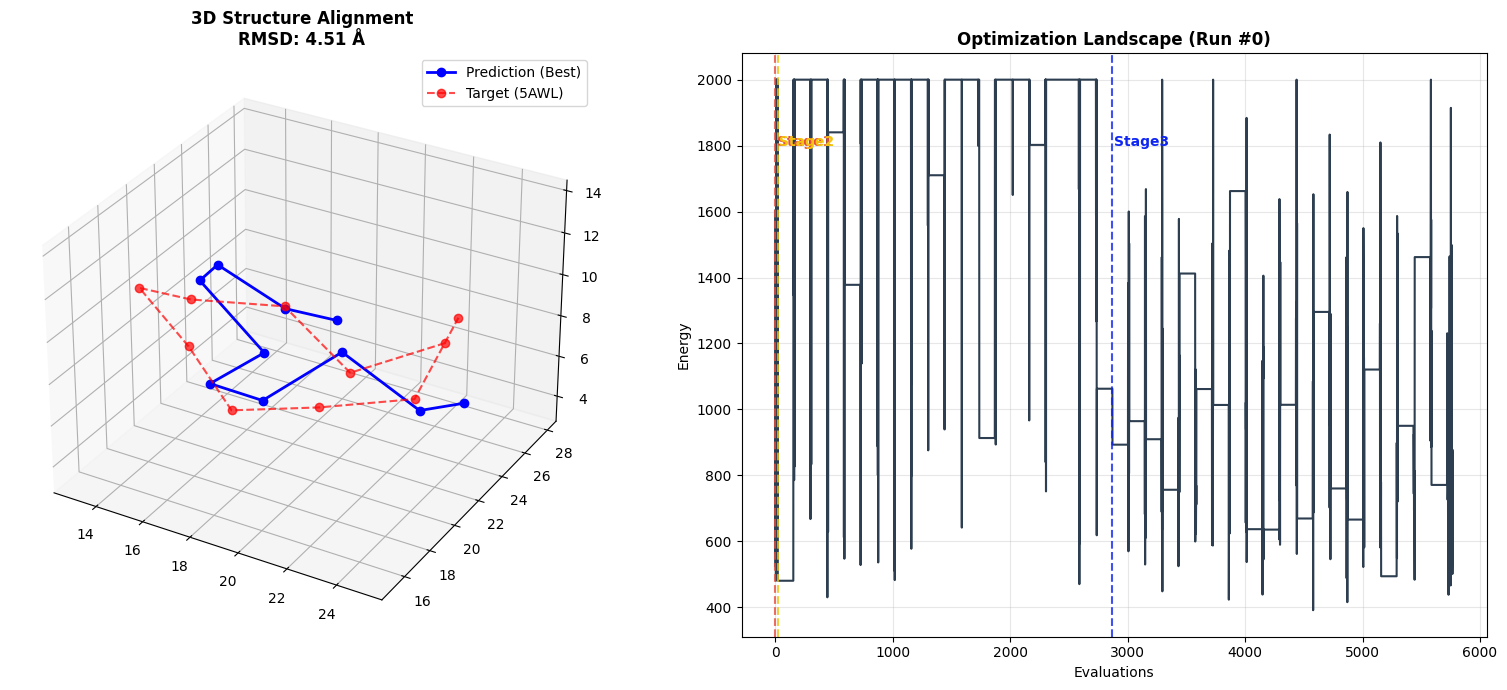

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import urllib.request
import os

def get_ground_truth_backbone(pdb_id="5AWL"):
    url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
    filename = f"{pdb_id}.pdb"
    if not os.path.exists(filename): urllib.request.urlretrieve(url, filename)
    coords_ca = []
    with open(filename, 'r') as f:
        for line in f:
            if line.startswith("ENDMDL"): break
            if line.startswith("ATOM") and "CA" in line[12:16]:
                coords_ca.append([float(line[30:38]), float(line[38:46]), float(line[46:54])])
    return np.array(coords_ca)

def calculate_physics_metrics(coords):
    end_to_end = np.linalg.norm(coords[0] - coords[-1])
    centroid = np.mean(coords, axis=0)
    rg = np.sqrt(np.mean(np.sum((coords - centroid)**2, axis=1)))
    return end_to_end, rg

if __name__ == "__main__":
    # 1. Setup Chignolin Sequence
    sequence = "YYDPETGTWY" 
    print(f"--- DIAGNOSING BACKBONE: {sequence} ---")
    
    # 2. Initialize Folder & Manager
    folder = QuantumBiophysicsFolder(sequence, force_field="amber")
    manager = EnsembleFoldingManager(folder)
    
    # 3. Run Ensemble (Using the Smart Initialization) 
    # We run 3 replicas with mixed strategies (Helix, Sheet, Random)
    manager.run_ensemble(n_runs=3, prime_strategy='random')
    
    # 4. Get Best Result
    best_result = manager.evaluate_best()
    final_coords = best_result['coords']
    tracker = best_result['tracker']
    
    # 5. Extract Backbone (CA) for Validation
    # Filter labels where atom name is 'CA'
    pred_ca = np.array([final_coords[i] for i, lbl in enumerate(folder.static_labels) if lbl[1] == 'CA'])
    true_ca = get_ground_truth_backbone("5AWL")
    
    # Truncate to match lengths (in case of differing caps)
    n = min(len(pred_ca), len(true_ca))
    pred_ca = pred_ca[:n]; true_ca = true_ca[:n]
    
    # 6. Calculate Metrics
    p_e2e, p_rg = calculate_physics_metrics(pred_ca)
    t_e2e, t_rg = calculate_physics_metrics(true_ca)
    
    print(f"\nMetric             | Predicted | Target (5AWL) | Status")
    print(f"-------------------|-----------|---------------|-------")
    print(f"End-to-End Dist    | {p_e2e:6.2f} Å | {t_e2e:6.2f} Å      | {'EXPANDED' if p_e2e > t_e2e + 5 else 'GOOD'}")
    print(f"Radius of Gyration | {p_rg:6.2f} Å | {t_rg:6.2f} Å      | {'PUFFY' if p_rg > t_rg + 2 else 'COMPACT'}")
    
    # 7. RMSD & Dual Plots
    rmsd, aligned_pred = StabilityAnalyzer.kabsch_rmsd(pred_ca, true_ca)
    print(f"\nBackbone RMSD: {rmsd:.3f} Å")
    
    fig = plt.figure(figsize=(16, 7))
    
    # PLOT 1: 3D Structure Comparison 
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot(aligned_pred[:,0], aligned_pred[:,1], aligned_pred[:,2], '-o', c='blue', label='Prediction (Best)', lw=2)
    ax1.plot(true_ca[:,0], true_ca[:,1], true_ca[:,2], '--o', c='red', label='Target (5AWL)', alpha=0.7)
    ax1.set_title(f"3D Structure Alignment\nRMSD: {rmsd:.2f} Å", fontsize=12, fontweight='bold')
    ax1.legend()
    
    # PLOT 2: Energy Landscape of the Winner
    ax2 = fig.add_subplot(122)
    energies = np.array(tracker.history)
    energies = np.clip(energies, -1000, 2000) # Clip visuals
    ax2.plot(energies, color='#2c3e50', lw=1.5, label='Hamiltonian Energy')
    
    colors = ['#e74c3c', '#f1c40f', '#0f26f1']
    for i, (idx, name) in enumerate(tracker.stage_markers):
        if idx < len(energies):
            ax2.axvline(x=idx, color=colors[i], linestyle='--', alpha=0.8)
            ax2.text(idx + 10, max(energies)*0.9, name, color=colors[i], fontweight='bold')
            
    ax2.set_title(f"Optimization Landscape (Run #{best_result['id']})", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Evaluations")
    ax2.set_ylabel("Energy")
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()